In [14]:
import sys
# Tell Python to look inside the downloaded repository code folder
sys.path.append(r"../ThinkDSP/code")

import thinkdsp
import numpy as np
import matplotlib.pyplot as plt

In [3]:
signal = thinkdsp.SinSignal(freq=440)
duration = signal.period * 30.25
wave = signal.make_wave(duration)
spectrum = wave.make_spectrum()

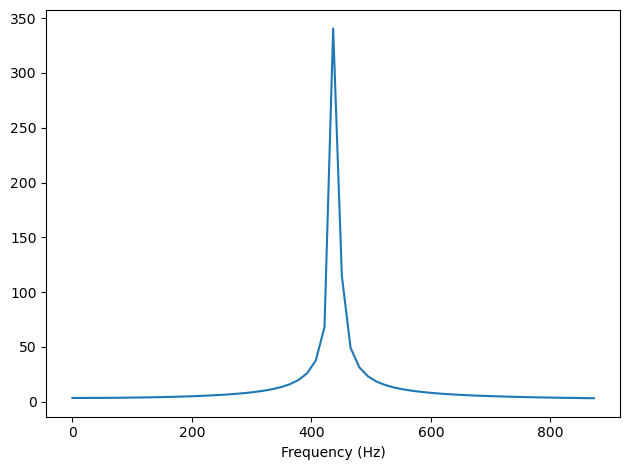

In [4]:
spectrum.plot(high=880)
thinkdsp.decorate(xlabel='Frequency (Hz)')

In [9]:
from IPython.display import Audio
Audio(data = wave.ys, rate = wave.framerate)

In [10]:
wave.make_audio()

In [15]:
PI2 = 2 * np.pi

class SawtoothChirp(thinkdsp.Chirp):
    """Represents a sawtooth signal with varying frequency."""

    def evaluate(self, ts):
        """Helper function that evaluates the signal.

        ts: float array of times
        """
        freqs = np.linspace(self.start, self.end, len(ts))
        dts = np.diff(ts, prepend=0)
        dphis = PI2 * freqs * dts
        phases = np.cumsum(dphis)
        cycles = phases / PI2
        frac, _ = np.modf(cycles)
        ys =  thinkdsp.normalize(thinkdsp.unbias(frac), self.amp)
        return ys

In [17]:
signal = SawtoothChirp(start=10, end=880)
wave = signal.make_wave(duration=5, framerate=4000)
wave.apodize()
wave.make_audio()

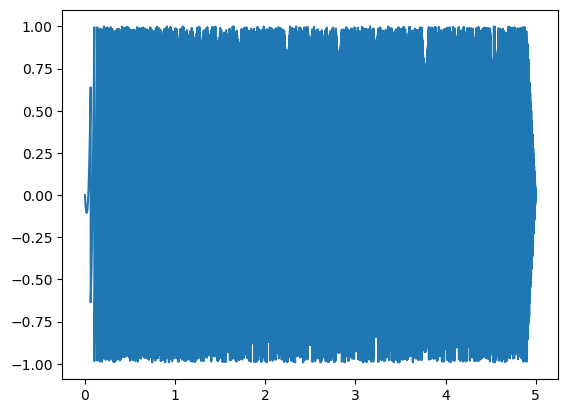

In [18]:
wave.plot()

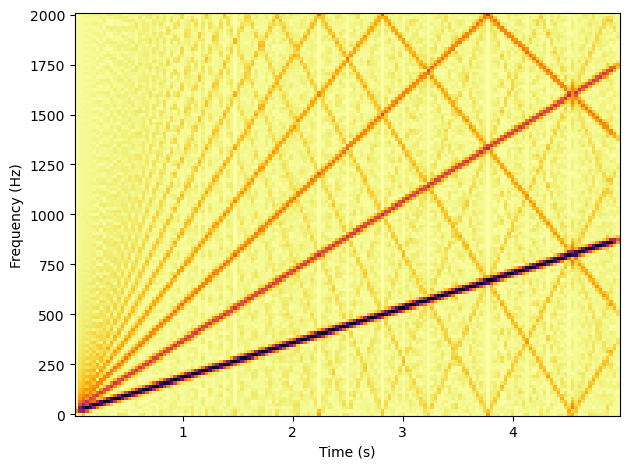

In [21]:
sp = wave.make_spectrogram(256)
sp.plot()
thinkdsp.decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')


In [23]:
wave1 = thinkdsp.read_wave('../ThinkDSP/code/tos-redalert.wav')
wave1.make_audio()

d:\Year 3 Term 1\3. Digital Signal Processing\ThinkDSP_Exercises\../ThinkDSP/code\thinkdsp.py:1112: RuntimeWarning: overflow encountered in scalar absolute
  high, low = abs(max(ys)), abs(min(ys))


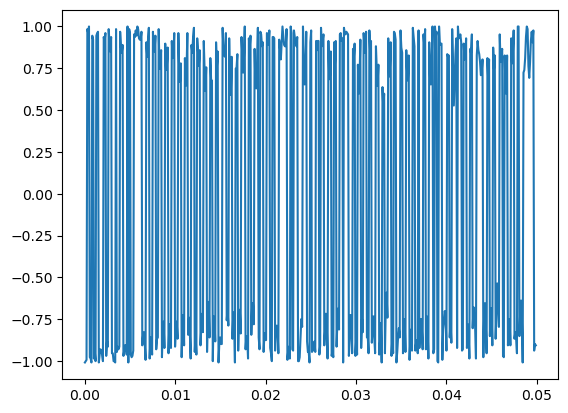

In [34]:
segment = wave1.segment(start = 0, duration = 0.05)
segment.plot()
segment.make_audio()